# Category EDA — Empirical Analysis

Goal: derive accurate, data-driven descriptions of what distinguishes each category (Tech, Speed, Accuracy, Standard, Extreme) from the actual training data.

Steps:
1. Load data and show class distribution
2. Feature importances from the XGBoost baseline model
3. Per-category medians on top features
4. Statistical significance (Kruskal-Wallis + pairwise Mann-Whitney U)
5. Visualisations (violin plots)
6. Summary conclusions

In [24]:
import json
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='tab10')
CATS = ['Tech', 'Speed', 'Accuracy', 'Standard', 'Extreme']

## Feature reference

See [`docs/FEATURES.md`](../docs/FEATURES.md) for a full description of every feature group and column.

## 1. Load data

In [25]:
df = pd.read_csv('../data/processed/pattern_features_merged.csv')
df = df[df['category'].isin(CATS)].copy()

print(f'Dataset: {len(df)} maps, {df.shape[1]} columns')
print()
print(df['category'].value_counts())

Dataset: 493 maps, 225 columns

category
Tech        144
Speed       103
Accuracy     91
Extreme      79
Standard     76
Name: count, dtype: int64


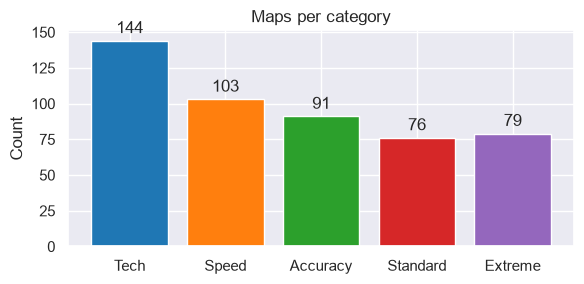

In [26]:
fig, ax = plt.subplots(figsize=(6, 3))
counts = df['category'].value_counts().reindex(CATS)
bars = ax.bar(counts.index, counts.values, color=sns.color_palette('tab10', 5))
ax.bar_label(bars, padding=3)
ax.set_title('Maps per category')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Feature importances (XGBoost baseline)

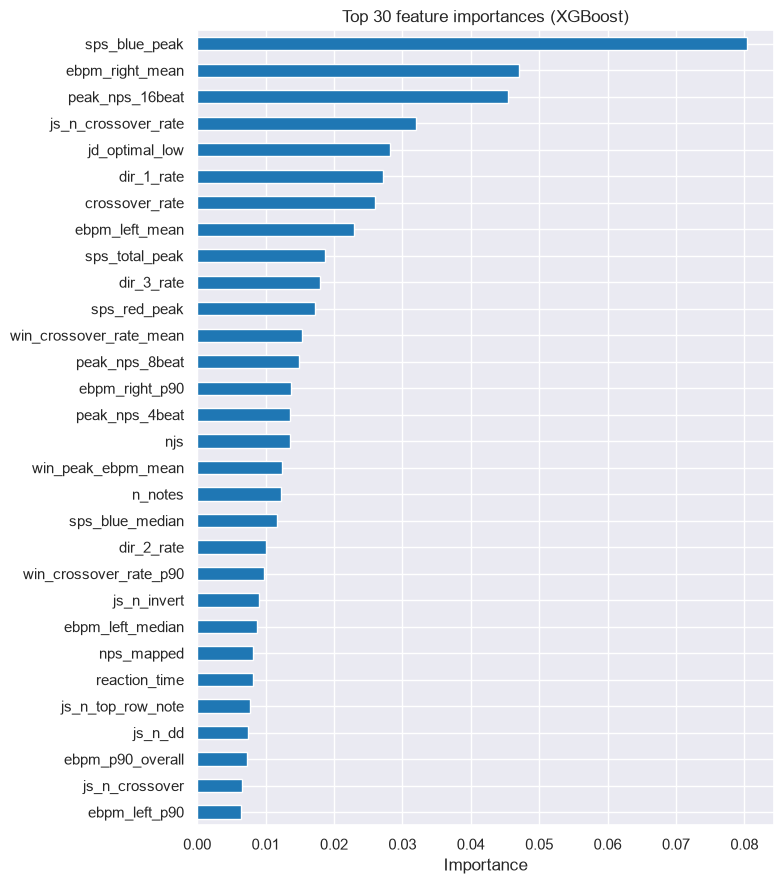

Top 30 features:
sps_blue_peak              0.080314
ebpm_right_mean            0.047054
peak_nps_16beat            0.045380
js_n_crossover_rate        0.032007
jd_optimal_low             0.028193
dir_1_rate                 0.027102
crossover_rate             0.025938
ebpm_left_mean             0.022863
sps_total_peak             0.018621
dir_3_rate                 0.017977
sps_red_peak               0.017195
win_crossover_rate_mean    0.015341
peak_nps_8beat             0.014941
ebpm_right_p90             0.013740
peak_nps_4beat             0.013638
njs                        0.013599
win_peak_ebpm_mean         0.012339
n_notes                    0.012318
sps_blue_median            0.011613
dir_2_rate                 0.010009
win_crossover_rate_p90     0.009799
js_n_invert                0.009059
ebpm_left_median           0.008684
nps_mapped                 0.008122
reaction_time              0.008120
js_n_top_row_note          0.007784
js_n_dd                    0.007386
ebpm_p90_ov

In [27]:
with open('../models/baseline_models/xgboost.pkl', 'rb') as f:
    xgb = pickle.load(f)

feature_cols = list(xgb.feature_names_in_)
importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

TOP_N = 30
top_features = importances.head(TOP_N)

fig, ax = plt.subplots(figsize=(8, 9))
top_features[::-1].plot.barh(ax=ax)
ax.set_title(f'Top {TOP_N} feature importances (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 30 features:')
print(top_features.to_string())

## 3. Per-category medians on top features

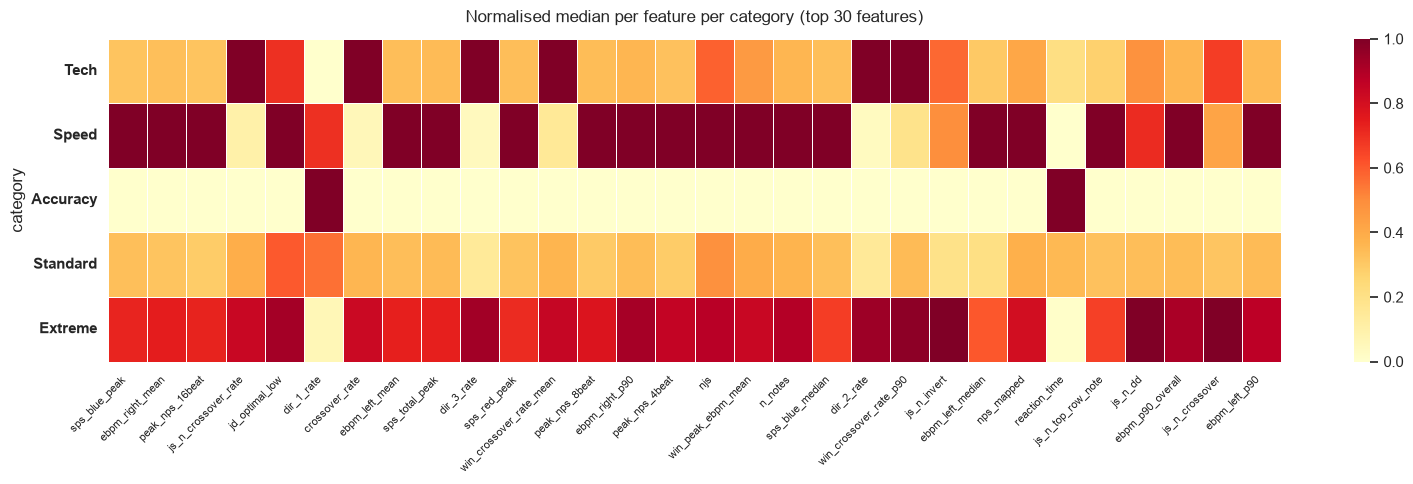


Raw medians:


'category                        Tech        Speed    Accuracy     Standard      Extreme\nsps_blue_peak               4.300000     9.000000    2.100000     4.400000     7.100000\nebpm_right_mean           123.732294   251.713916   59.160039   120.088102   202.501937\npeak_nps_16beat             9.916667    21.778125    4.359375     9.408854    17.050000\njs_n_crossover_rate         0.363782     0.135083    0.109726     0.208905     0.322593\njd_optimal_low             17.052632    17.200000   16.714286    17.006849    17.162791\ndir_1_rate                  0.132428     0.305658    0.380779     0.270226     0.147287\ncrossover_rate              0.363782     0.135083    0.121657     0.208905     0.322593\nebpm_left_mean            121.046968   242.880867   58.543629   120.556665   194.552497\nsps_total_peak              8.300000    16.500000    4.000000     8.300000    13.200000\ndir_3_rate                  0.070606     0.002913    0.000000     0.010467     0.065421\nsps_red_peak        

In [28]:
top_feat_list = top_features.index.tolist()
medians = df.groupby('category')[top_feat_list].median().reindex(CATS)

# Normalise each feature to [0, 1] for heatmap readability
medians_norm = (medians - medians.min()) / (medians.max() - medians.min() + 1e-9)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    medians_norm,
    ax=ax,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.5,
    linecolor='white',
    xticklabels=True,
    yticklabels=True,
)
ax.set_title('Normalised median per feature per category (top 30 features)', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11, fontweight='bold')
ax.tick_params(axis='y', length=0, pad=8)
plt.tight_layout()
plt.show()

print('\nRaw medians:')
medians.T.to_string()

In [29]:
# Show absolute medians for the top 15 most important features
medians[top_feat_list[:15]].T.style.background_gradient(cmap='YlOrRd', axis=1)

category,Tech,Speed,Accuracy,Standard,Extreme
sps_blue_peak,4.300000,9.000000,2.100000,4.400000,7.100000
ebpm_right_mean,123.732294,251.713916,59.160039,120.088102,202.501937
peak_nps_16beat,9.916667,21.778125,4.359375,9.408854,17.050000
js_n_crossover_rate,0.363782,0.135083,0.109726,0.208905,0.322593
jd_optimal_low,17.052632,17.200000,16.714286,17.006849,17.162791
dir_1_rate,0.132428,0.305658,0.380779,0.270226,0.147287
crossover_rate,0.363782,0.135083,0.121657,0.208905,0.322593
ebpm_left_mean,121.046968,242.880867,58.543629,120.556665,194.552497
sps_total_peak,8.300000,16.500000,4.000000,8.300000,13.200000
dir_3_rate,0.070606,0.002913,0.000000,0.010467,0.065421


## 4. Statistical significance

Kruskal-Wallis (non-parametric ANOVA across all 5 categories), then pairwise Mann-Whitney U with Bonferroni correction on top features.

In [30]:
kw_results = []
for feat in top_feat_list:
    groups = [df[df['category'] == c][feat].dropna().values for c in CATS]
    stat, p = stats.kruskal(*groups)
    kw_results.append({'feature': feat, 'kw_stat': stat, 'p_value': p, 'significant': p < 0.05})

kw_df = pd.DataFrame(kw_results).sort_values('kw_stat', ascending=False)
print(f'Significant (p<0.05): {kw_df["significant"].sum()} / {len(kw_df)}')
print()
kw_df[['feature', 'kw_stat', 'p_value', 'significant']].head(20).to_string(index=False)

Significant (p<0.05): 30 / 30



'           feature    kw_stat      p_value  significant\n    ebpm_left_mean 402.325400 8.746825e-86         True\n   ebpm_right_mean 401.956339 1.050980e-85         True\n   peak_nps_16beat 391.136542 2.287139e-83         True\n     sps_blue_peak 389.092087 6.323767e-83         True\n               njs 388.891766 6.986384e-83         True\n    jd_optimal_low 388.891766 6.986384e-83         True\n    peak_nps_8beat 388.450906 8.699494e-83         True\n      sps_red_peak 386.138210 2.748586e-82         True\n    sps_total_peak 382.575178 1.617361e-81         True\n     ebpm_left_p90 381.352425 2.971265e-81         True\n    peak_nps_4beat 380.858976 3.797808e-81         True\n  ebpm_p90_overall 380.851483 3.811988e-81         True\n    ebpm_right_p90 380.676283 4.159077e-81         True\n        nps_mapped 379.572739 7.200693e-81         True\n  ebpm_left_median 346.388323 1.056246e-73         True\nwin_peak_ebpm_mean 327.780344 1.097988e-69         True\n js_n_top_row_note 325.234506 

In [31]:
# Pairwise Mann-Whitney U for top 10 features
n_comparisons = len(list(combinations(CATS, 2)))  # 10 pairs
alpha_bonferroni = 0.05 / n_comparisons

print(f'Bonferroni-corrected alpha: {alpha_bonferroni:.4f}\n')

for feat in top_feat_list[:10]:
    print(f'--- {feat} ---')
    for c1, c2 in combinations(CATS, 2):
        g1 = df[df['category'] == c1][feat].dropna()
        g2 = df[df['category'] == c2][feat].dropna()
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '***' if p < alpha_bonferroni else ('*' if p < 0.05 else '')
        if sig:
            m1, m2 = g1.median(), g2.median()
            direction = '>' if m1 > m2 else '<'
            print(f'  {c1} {direction} {c2}  (p={p:.4f}) {sig}  medians: {m1:.3f} vs {m2:.3f}')
    print()

Bonferroni-corrected alpha: 0.0050

--- sps_blue_peak ---
  Tech < Speed  (p=0.0000) ***  medians: 4.300 vs 9.000
  Tech > Accuracy  (p=0.0000) ***  medians: 4.300 vs 2.100
  Tech < Extreme  (p=0.0000) ***  medians: 4.300 vs 7.100
  Speed > Accuracy  (p=0.0000) ***  medians: 9.000 vs 2.100
  Speed > Standard  (p=0.0000) ***  medians: 9.000 vs 4.400
  Speed > Extreme  (p=0.0000) ***  medians: 9.000 vs 7.100
  Accuracy < Standard  (p=0.0000) ***  medians: 2.100 vs 4.400
  Accuracy < Extreme  (p=0.0000) ***  medians: 2.100 vs 7.100
  Standard < Extreme  (p=0.0000) ***  medians: 4.400 vs 7.100

--- ebpm_right_mean ---
  Tech < Speed  (p=0.0000) ***  medians: 123.732 vs 251.714
  Tech > Accuracy  (p=0.0000) ***  medians: 123.732 vs 59.160
  Tech < Extreme  (p=0.0000) ***  medians: 123.732 vs 202.502
  Speed > Accuracy  (p=0.0000) ***  medians: 251.714 vs 59.160
  Speed > Standard  (p=0.0000) ***  medians: 251.714 vs 120.088
  Speed > Extreme  (p=0.0000) ***  medians: 251.714 vs 202.502
  Ac

## 5. Violin plots — top distinguishing features

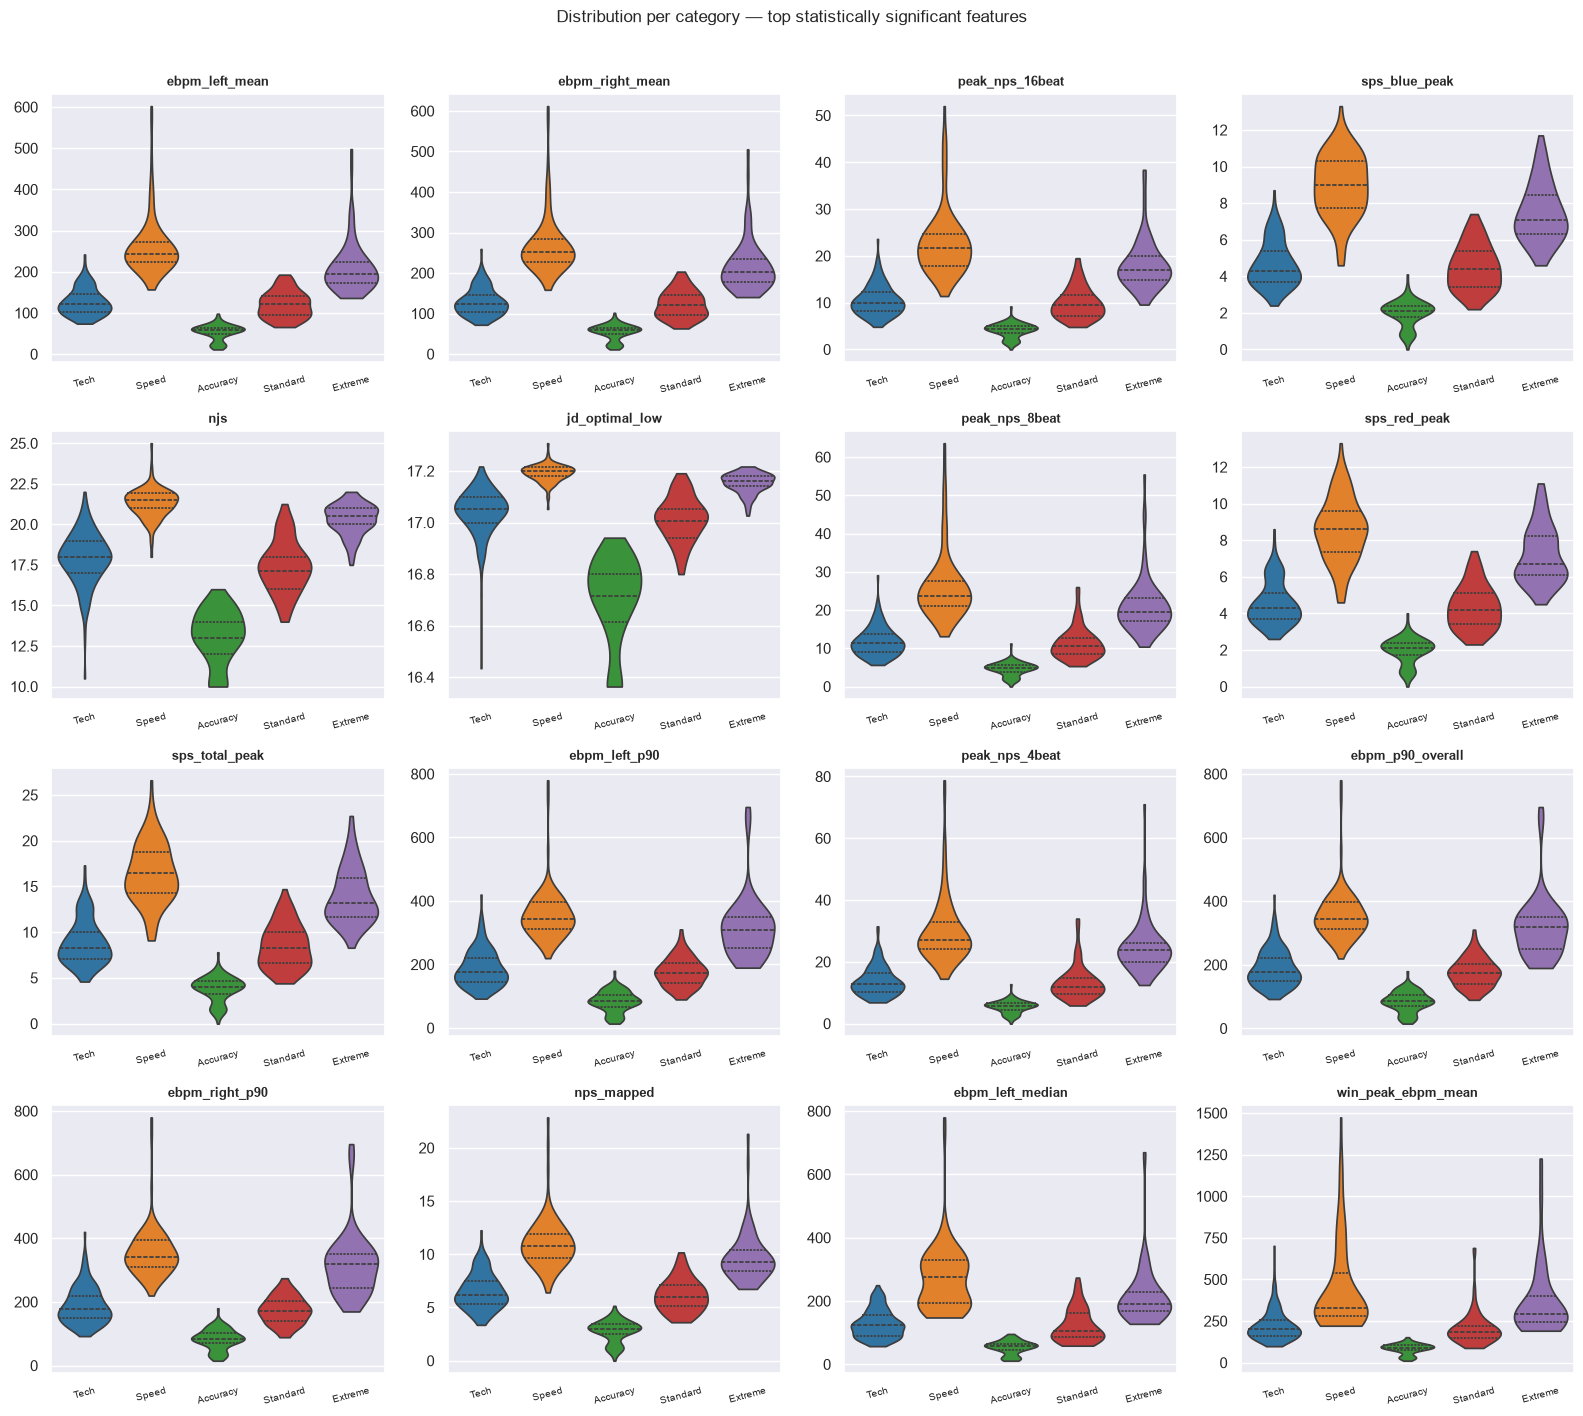

In [32]:
# Pick features significant in Kruskal-Wallis, ordered by KW stat
sig_features = kw_df[kw_df['significant']]['feature'].tolist()[:16]

n_cols = 4
n_rows = (len(sig_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

palette = dict(zip(CATS, sns.color_palette('tab10', 5)))

for i, feat in enumerate(sig_features):
    ax = axes[i]
    plot_df = df[df['category'].isin(CATS)][['category', feat]].dropna()
    sns.violinplot(
        data=plot_df,
        x='category',
        y=feat,
        order=CATS,
        palette=palette,
        ax=ax,
        inner='quartile',
        cut=0,
    )
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution per category — top statistically significant features', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Category profiles — median z-scores

Express each category as a z-score profile over all significant features, so you can see at a glance where each category sits above/below the population mean.

In [ ]:
## 7. Conclusions

See [`docs/EDA_CONCLUSIONS.md`](../docs/EDA_CONCLUSIONS.md) for the full written conclusions derived from this analysis.

In [34]:
# Helper: for each category, print top 5 features where it scores highest and lowest z
for cat in CATS:
    row = z_medians.loc[cat].sort_values(ascending=False)
    print(f'\n=== {cat} ===')
    print('  HIGH:', ', '.join(f'{f} ({v:+.2f})' for f, v in row.head(5).items()))
    print('  LOW: ', ', '.join(f'{f} ({v:+.2f})' for f, v in row.tail(5).items()))


=== Tech ===
  HIGH: jd_optimal_low (+0.15), njs (-0.01), nps_mapped (-0.30), ebpm_left_median (-0.33), win_peak_ebpm_mean (-0.33)
  LOW:  ebpm_right_p90 (-0.40), peak_nps_16beat (-0.40), ebpm_left_p90 (-0.41), peak_nps_4beat (-0.41), sps_blue_peak (-0.43)

=== Speed ===
  HIGH: sps_blue_peak (+1.28), sps_red_peak (+1.26), sps_total_peak (+1.23), ebpm_left_median (+1.17), njs (+1.12)
  LOW:  ebpm_right_p90 (+1.00), peak_nps_8beat (+0.93), jd_optimal_low (+0.92), peak_nps_4beat (+0.88), win_peak_ebpm_mean (+0.31)

=== Accuracy ===
  HIGH: win_peak_ebpm_mean (-0.86), ebpm_left_median (-0.98), peak_nps_4beat (-1.05), peak_nps_8beat (-1.06), peak_nps_16beat (-1.10)
  LOW:  sps_blue_peak (-1.23), sps_total_peak (-1.24), nps_mapped (-1.26), jd_optimal_low (-1.63), njs (-1.63)

=== Standard ===
  HIGH: jd_optimal_low (-0.09), njs (-0.30), nps_mapped (-0.37), sps_total_peak (-0.39), ebpm_left_mean (-0.39)
  LOW:  ebpm_right_p90 (-0.43), peak_nps_16beat (-0.46), peak_nps_8beat (-0.46), peak_np